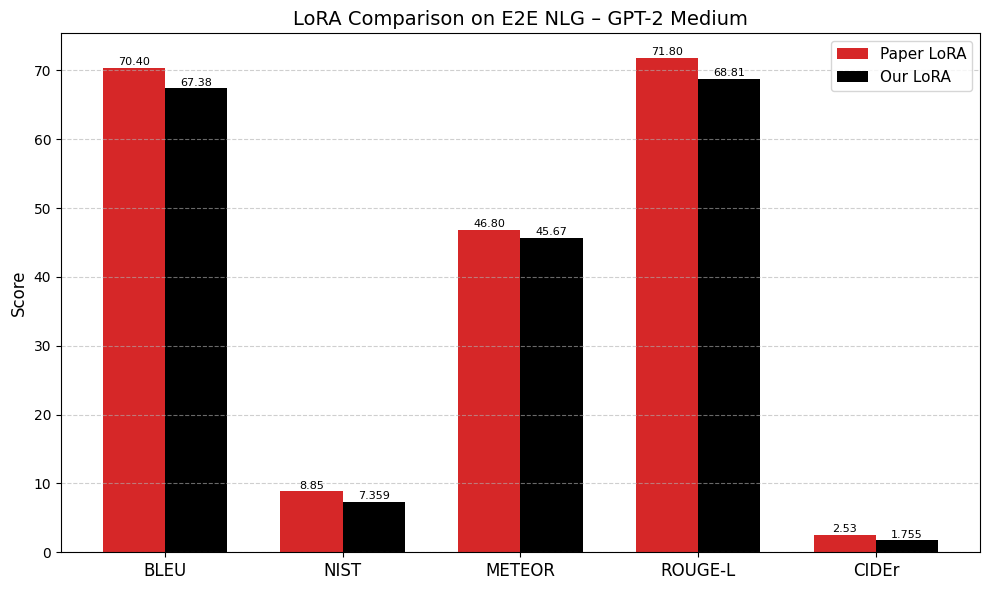

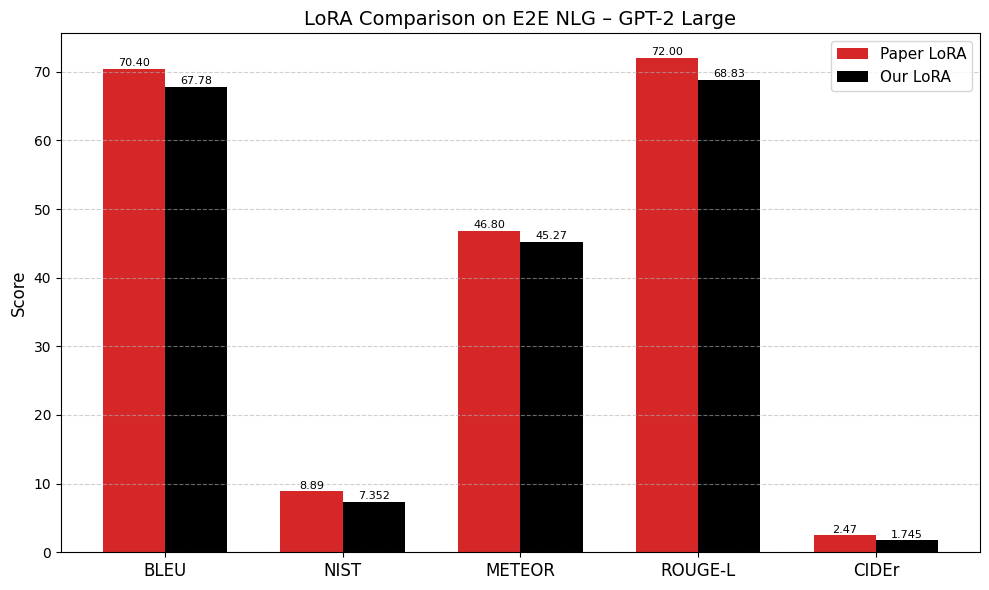

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. Hard-coded data from Table 3 (paper) and user's results
# ----------------------------------------------------------------------

metrics = ['BLEU', 'NIST', 'METEOR', 'ROUGE-L', 'CIDEr']

# Paper LoRA means (no error bars in this comparison)
paper_medium_lora = [70.4,  8.85, 46.8, 71.8, 2.53]   # 'LoRA (0.35M)*'
paper_large_lora  = [70.4,  8.89, 46.8, 72.0, 2.47]   # 'LoRA (0.77M)*'

# User's results (from gpt2-medium_results.json & gpt2-large_results.json)
user_medium_lora = [67.38, 7.3585, 45.67, 68.81, 1.7553]
user_large_lora  = [67.78, 7.3522, 45.27, 68.83, 1.7454]

# ----------------------------------------------------------------------
# 2. Helper function to plot a grouped bar chart
# ----------------------------------------------------------------------
PAPER_COLOR = '#d62728'   # red
USER_COLOR  = '#000000'   # black

def plot_comparison(paper_vals, user_vals, model_size, filename):
    x = np.arange(len(metrics))          # label positions
    width = 0.35                          # bar width

    fig, ax = plt.subplots(figsize=(10, 6))

    # Paper LoRA bars
    bars1 = ax.bar(x - width/2, paper_vals, width, label='Paper LoRA', color=PAPER_COLOR)
    # User LoRA bars
    bars2 = ax.bar(x + width/2, user_vals, width, label='Our LoRA', color=USER_COLOR)

    # Aesthetics
    ax.set_title(f'LoRA Comparison on E2E NLG – GPT-2 {model_size}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Add value labels above each bar
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.4g}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# ----------------------------------------------------------------------
# 3. Generate plots for Medium and Large
# ----------------------------------------------------------------------
plot_comparison(paper_medium_lora, user_medium_lora,
                'Medium', 'gpt2_medium_lora_comparison.png')
plot_comparison(paper_large_lora, user_large_lora,
                'Large', 'gpt2_large_lora_comparison.png')